In [26]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [27]:
columns = ["SepalLength", "SepalWidth", "PetalLength", "PetalWidth", "Species"]

df = pd.read_csv(
    "../data/iris.data",
    sep=r"\s+",
    skiprows=2,
    names=columns
)

df.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
0,5.1,3.5,1.4,0.2,Se
1,4.9,3.0,1.4,0.2,Se
2,4.7,3.2,1.3,0.2,Se
3,4.6,3.1,1.5,0.2,Se
4,5.0,3.6,1.4,0.2,Se


In [28]:
df.info()
df["Species"].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SepalLength  150 non-null    float64
 1   SepalWidth   150 non-null    float64
 2   PetalLength  150 non-null    float64
 3   PetalWidth   150 non-null    float64
 4   Species      150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


Species
Se    50
Ve    50
Vi    50
Name: count, dtype: int64

In [29]:
X = df[["SepalLength", "SepalWidth", "PetalLength", "PetalWidth"]]
y_true = df["Species"]

In [30]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [31]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

df.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Species,Cluster
0,5.1,3.5,1.4,0.2,Se,1
1,4.9,3.0,1.4,0.2,Se,1
2,4.7,3.2,1.3,0.2,Se,1
3,4.6,3.1,1.5,0.2,Se,1
4,5.0,3.6,1.4,0.2,Se,1


In [32]:
pd.crosstab(df["Species"], df["Cluster"])

Cluster,0,1,2
Species,,,
Se,0,50,0
Ve,39,0,11
Vi,14,0,36


In [33]:
cluster_to_species = {}

for cluster in sorted(df["Cluster"].unique()):
    most_common_species = df[df["Cluster"] == cluster]["Species"].mode()[0]
    cluster_to_species[cluster] = most_common_species

cluster_to_species

df["PredictedSpecies"] = df["Cluster"].map(cluster_to_species)

df.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Species,Cluster,PredictedSpecies
0,5.1,3.5,1.4,0.2,Se,1,Se
1,4.9,3.0,1.4,0.2,Se,1,Se
2,4.7,3.2,1.3,0.2,Se,1,Se
3,4.6,3.1,1.5,0.2,Se,1,Se
4,5.0,3.6,1.4,0.2,Se,1,Se


In [34]:
labels = ["Se", "Ve", "Vi"]

cm = confusion_matrix(y_true, df["PredictedSpecies"], labels=labels)

confusion_df = pd.DataFrame(
    cm,
    index=["Actual Se", "Actual Ve", "Actual Vi"],
    columns=["Predicted Se", "Predicted Ve", "Predicted Vi"]
)

confusion_df

,Predicted Se,Predicted Ve,Predicted Vi
Actual Se,50,0,0
Actual Ve,0,39,11
Actual Vi,0,14,36


In [35]:
results = []

for i, label in enumerate(labels):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    
    results.append({
        "Class": label,
        "True Positive": TP,
        "False Negative": FN
    })

results_df = pd.DataFrame(results)
results_df

,Class,True Positive,False Negative
0,Se,50,0
1,Ve,39,11
2,Vi,36,14


In [36]:
accuracy = accuracy_score(y_true, df["PredictedSpecies"])

print("Accuracy:", accuracy)

print(classification_report(y_true, df["PredictedSpecies"], labels=labels))

Accuracy: 0.8333333333333334
              precision    recall  f1-score   support

          Se       1.00      1.00      1.00        50
          Ve       0.74      0.78      0.76        50
          Vi       0.77      0.72      0.74        50

    accuracy                           0.83       150
   macro avg       0.83      0.83      0.83       150
weighted avg       0.83      0.83      0.83       150



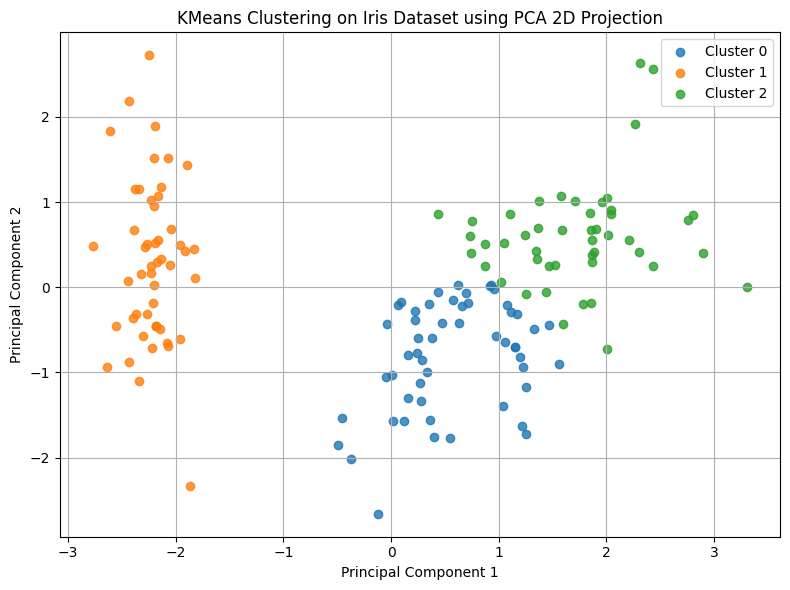

In [37]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reduce 4D Iris features into 2D for visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

plt.figure(figsize=(8, 6))

for cluster in sorted(df["Cluster"].unique()):
    cluster_data = df[df["Cluster"] == cluster]
    plt.scatter(
        cluster_data["PCA1"],
        cluster_data["PCA2"],
        label=f"Cluster {cluster}",
        alpha=0.8
    )

plt.title("KMeans Clustering on Iris Dataset using PCA 2D Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("kmeans_iris_clusters_pca.png", dpi=300)
plt.show()

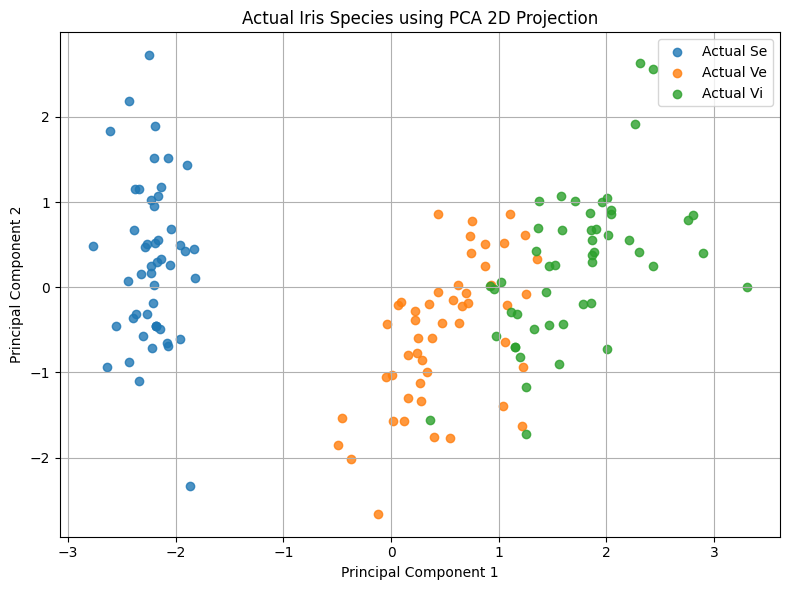

In [38]:
plt.figure(figsize=(8, 6))

for species in labels:
    species_data = df[df["Species"] == species]
    plt.scatter(
        species_data["PCA1"],
        species_data["PCA2"],
        label=f"Actual {species}",
        alpha=0.8
    )

plt.title("Actual Iris Species using PCA 2D Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("actual_iris_species_pca.png", dpi=300)
plt.show()

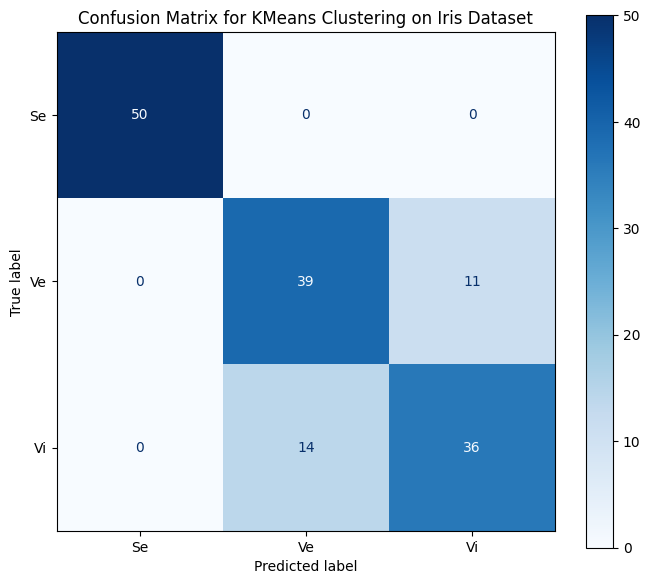

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")

plt.title("Confusion Matrix for KMeans Clustering on Iris Dataset")
plt.tight_layout()

plt.savefig("kmeans_iris_confusion_matrix.png", dpi=300)
plt.show()

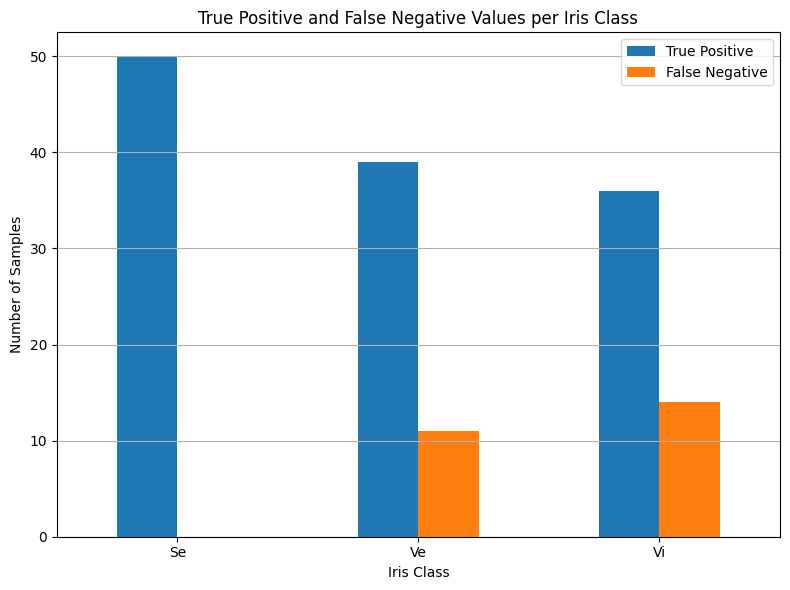

In [40]:
results_df.plot(
    x="Class",
    y=["True Positive", "False Negative"],
    kind="bar",
    figsize=(8, 6)
)

plt.title("True Positive and False Negative Values per Iris Class")
plt.xlabel("Iris Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()

plt.savefig("kmeans_iris_tp_fn_bar_chart.png", dpi=300)
plt.show()

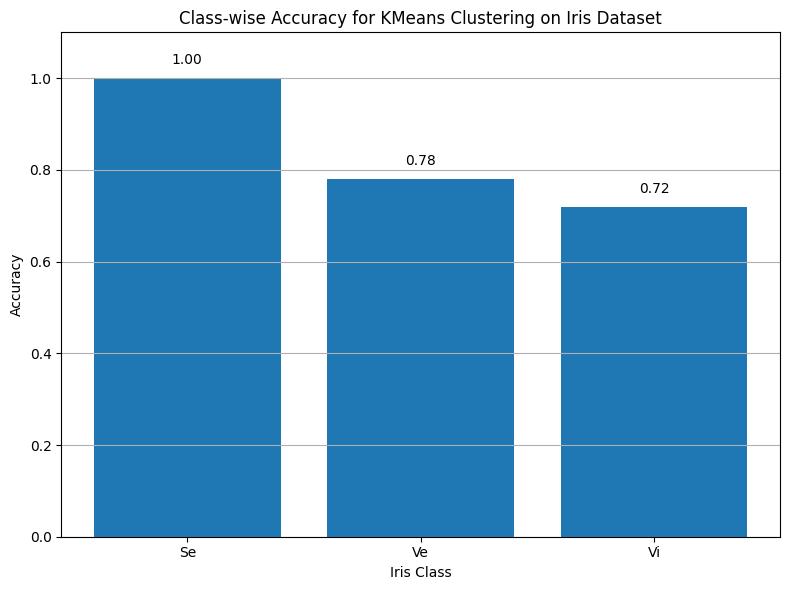

In [41]:
accuracy_results = []

for i, label in enumerate(labels):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    
    class_accuracy = TP / (TP + FN)
    
    accuracy_results.append({
        "Class": label,
        "Class Accuracy": class_accuracy
    })

accuracy_df = pd.DataFrame(accuracy_results)

accuracy_df

plt.figure(figsize=(8, 6))

plt.bar(
    accuracy_df["Class"],
    accuracy_df["Class Accuracy"]
)

plt.title("Class-wise Accuracy for KMeans Clustering on Iris Dataset")
plt.xlabel("Iris Class")
plt.ylabel("Accuracy")
plt.ylim(0, 1.1)
plt.grid(axis="y")

for index, row in accuracy_df.iterrows():
    plt.text(
        index,
        row["Class Accuracy"] + 0.03,
        f"{row['Class Accuracy']:.2f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig("kmeans_iris_class_accuracy.png", dpi=300)
plt.show()

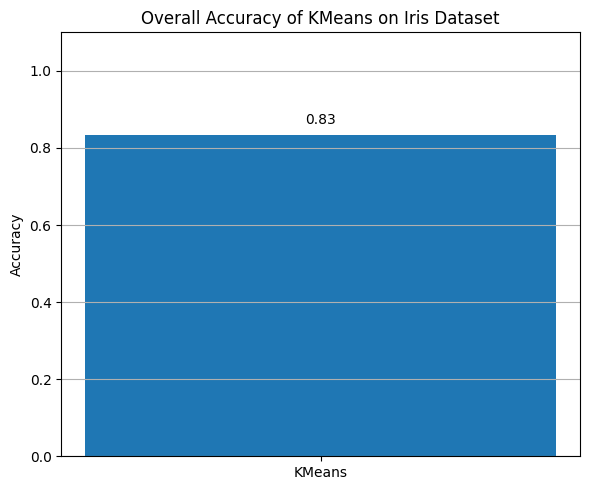

Overall Accuracy: 0.8333333333333334


In [42]:
overall_accuracy = accuracy_score(y_true, df["PredictedSpecies"])

plt.figure(figsize=(6, 5))

plt.bar(["KMeans"], [overall_accuracy])

plt.title("Overall Accuracy of KMeans on Iris Dataset")
plt.ylabel("Accuracy")
plt.ylim(0, 1.1)
plt.grid(axis="y")

plt.text(
    0,
    overall_accuracy + 0.03,
    f"{overall_accuracy:.2f}",
    ha="center"
)

plt.tight_layout()

plt.savefig("kmeans_iris_overall_accuracy.png", dpi=300)
plt.show()

print("Overall Accuracy:", overall_accuracy)